# Cleaning Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/clinical_data.csv")

df.head()

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


In [18]:
print("Rows and columns:", df.shape)
print(df.columns.tolist())

Rows and columns: (6388, 74)
['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend', 'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn', 'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr', 'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2', 'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl', 'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid', 'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn', 'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca']


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6388 entries, 0 to 6387
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   caseid               6388 non-null   int64  
 1   subjectid            6388 non-null   int64  
 2   casestart            6388 non-null   int64  
 3   caseend              6388 non-null   int64  
 4   anestart             6388 non-null   int64  
 5   aneend               6388 non-null   float64
 6   opstart              6388 non-null   int64  
 7   opend                6388 non-null   int64  
 8   adm                  6388 non-null   int64  
 9   dis                  6388 non-null   int64  
 10  icu_days             6388 non-null   int64  
 11  death_inhosp         6388 non-null   int64  
 12  age                  6388 non-null   str    
 13  sex                  6388 non-null   str    
 14  height               6388 non-null   float64
 15  weight               6388 non-null   float64
 16 

In [20]:
df.describe()

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
count,6388.000000,6388.000000,6388.0,6388.000000,6388.000000,6.388000e+03,6388.000000,6388.000000,6.388000e+03,6.388000e+03,...,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000
mean,3194.500000,3047.726362,0.0,11348.680651,-757.002974,-5.666559e+05,2188.399029,10347.526769,-8.543255e+05,5.050752e+04,...,32.113807,39.776769,0.036944,17.043676,72.824828,0.016907,7.753601,32.631027,7.894646,120.781935
std,1844.201092,1757.857225,0.0,6658.506842,783.520044,4.618684e+07,995.381670,6602.562588,4.610906e+07,4.613061e+07,...,137.512127,54.534878,0.364006,38.029277,36.141193,0.444540,13.218972,160.513431,469.413023,535.113499
min,1.000000,1.000000,0.0,1640.000000,-19065.000000,-3.691470e+09,0.000000,786.000000,-3.685366e+09,-3.685366e+09,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1597.750000,1532.750000,0.0,6194.500000,-1090.250000,6.013750e+03,1440.000000,5253.750000,-2.250750e+05,2.086800e+05,...,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3194.500000,3053.500000,0.0,9924.500000,-583.000000,9.769500e+03,2055.000000,8877.000000,-2.010600e+05,3.932400e+05,...,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,5.000000,0.000000,0.000000,0.000000
75%,4791.250000,4569.250000,0.0,15072.750000,-277.000000,1.492950e+04,2779.000000,14014.000000,-1.293000e+05,6.496500e+05,...,0.000000,100.000000,0.000000,0.000000,90.000000,0.000000,10.000000,0.000000,0.000000,0.000000
max,6388.000000,6090.000000,0.0,62494.000000,1984.000000,1.107090e+05,13461.000000,60697.000000,-7.200000e+02,1.930788e+07,...,1900.000000,200.000000,8.000000,200.000000,330.000000,20.000000,300.000000,4100.000000,37220.000000,15900.000000


In [21]:
missing = df.isna().sum().sort_values(ascending=False)

missing.head(30)

cline2                 6328
lmasize                6286
aline2                 6283
preop_be               5856
preop_sao2             5855
preop_hco3             5855
preop_paco2            5850
preop_pao2             5850
preop_ph               5842
dltubesize             5458
iv2                    4951
cline1                 4847
aline1                 2925
intraop_uo             2681
intraop_ebl            2401
tubesize               1469
cormack                 835
preop_na                623
preop_k                 621
airway                  415
intraop_crystalloid     408
preop_aptt              402
preop_pt                390
preop_gluc              378
preop_cr                372
preop_alb               372
preop_ast               366
preop_bun               365
preop_alt               364
preop_hb                341
dtype: int64

In [22]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend',
       'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age',
       'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype',
       'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn',
       'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt',
       'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc',
       'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr',
       'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2',
       'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize',
       'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl',
       'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid',
       'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn',
       'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe',
    

In [23]:
import os
rename_cols = {
    "caseid": "case_id",
    "subjectid": "patient_id",
    "casestart": "case_start_time",
    "caseend": "case_end_time",
    "anestart": "anesthesia_start_time",
    "aneend": "anesthesia_end_time",
    "opstart": "operation_start_time",
    "opend": "operation_end_time",
    "adm": "admission_time_from_case_start_sec",
    "dis": "discharge_time_from_case_start_sec",
    "icu_days": "icu_days",
    "death_inhosp": "in_hospital_death",
    "age": "age",
    "sex": "sex",
    "height": "height",
    "weight": "weight",
    "bmi": "bmi",
    "asa": "asa_class",
    "emop": "emergency_operation",
    "department": "department",
    "optype": "operation_type",
    "dx": "diagnosis",
    "opname": "operation_name",
    "approach": "surgical_approach",
    "position": "patient_position",
    "ane_type": "anesthesia_type",
    "preop_htn": "preoperative_hypertension",
    "preop_dm": "preoperative_diabetes",
    "preop_ecg": "preoperative_ecg",
    "preop_pft": "preoperative_pulmonary_function_test",
    "preop_hb": "preoperative_hemoglobin",
    "preop_plt": "preoperative_platelet_count",
    "preop_pt": "preoperative_prothrombin_time",
    "preop_aptt": "preoperative_activated_partial_thromboplastin_time",
    "preop_na": "preoperative_sodium",
    "preop_k": "preoperative_potassium",
    "preop_gluc": "preoperative_glucose",
    "preop_alb": "preoperative_albumin",
    "preop_ast": "preoperative_ast",
    "preop_alt": "preoperative_alt",
    "preop_bun": "preoperative_blood_urea_nitrogen",
    "preop_cr": "preoperative_creatinine",
    "preop_ph": "preoperative_ph",
    "preop_hco3": "preoperative_bicarbonate",
    "preop_be": "preoperative_base_excess",
    "preop_pao2": "preoperative_pao2",
    "preop_paco2": "preoperative_paco2",
    "preop_sao2": "preoperative_oxygen_saturation",
    "cormack": "cormack_grade",
    "airway": "airway_type",
    "tubesize": "tube_size",
    "dltubesize": "double_lumen_tube_size",
    "lmasize": "laryngeal_mask_airway_size",
    "iv1": "iv_line_1",
    "iv2": "iv_line_2",
    "aline1": "arterial_line_1",
    "aline2": "arterial_line_2",
    "cline1": "central_line_1",
    "cline2": "central_line_2",
    "intraop_ebl": "intraoperative_estimated_blood_loss",
    "intraop_uo": "intraoperative_urine_output",
    "intraop_rbc": "intraoperative_red_blood_cell_transfusion",
    "intraop_ffp": "intraoperative_fresh_frozen_plasma_transfusion",
    "intraop_crystalloid": "intraoperative_crystalloid",
    "intraop_colloid": "intraoperative_colloid",
    "intraop_ppf": "intraoperative_propofol",
    "intraop_mdz": "intraoperative_midazolam",
    "intraop_ftn": "intraoperative_fentanyl",
    "intraop_rocu": "intraoperative_rocuronium",
    "intraop_vecu": "intraoperative_vecuronium",
    "intraop_eph": "intraoperative_ephedrine",
    "intraop_phe": "intraoperative_phenylephrine",
    "intraop_epi": "intraoperative_epinephrine",
    "intraop_ca": "intraoperative_calcium"
}

df = df.rename(columns=rename_cols)

In [24]:
eda_cols = [
    "case_id",
    "patient_id",
    "admission_time_from_case_start_sec",
    "discharge_time_from_case_start_sec",
    "icu_days",
    "in_hospital_death",
    "age",
    "sex",
    "height",
    "weight",
    "bmi",
    "asa_class",
    "emergency_operation",
    "department",
    "operation_type",
    "diagnosis",
    "operation_name",
    "surgical_approach",
    "patient_position",
    "anesthesia_type",
    "preoperative_hypertension",
    "preoperative_diabetes",
    "preoperative_hemoglobin",
    "preoperative_platelet_count",
    "preoperative_creatinine",
    "intraoperative_estimated_blood_loss",
    "intraoperative_urine_output",
    "intraoperative_red_blood_cell_transfusion",
    "intraoperative_fresh_frozen_plasma_transfusion",
    "intraoperative_crystalloid",
    "intraoperative_colloid",
    "intraoperative_propofol",
    "intraoperative_midazolam",
    "intraoperative_fentanyl"
]

analysis_df = df[eda_cols].copy()

# Make sure these are numeric seconds
analysis_df["admission_time_from_case_start_sec"] = pd.to_numeric(
    analysis_df["admission_time_from_case_start_sec"],
    errors="coerce"
)

analysis_df["discharge_time_from_case_start_sec"] = pd.to_numeric(
    analysis_df["discharge_time_from_case_start_sec"],
    errors="coerce"
)

# Convert seconds to days
analysis_df["hospital_length_of_stay"] = (
    analysis_df["discharge_time_from_case_start_sec"]
    - analysis_df["admission_time_from_case_start_sec"]
) / 86400

# Remove impossible negative values
analysis_df.loc[
    analysis_df["hospital_length_of_stay"] < 0,
    "hospital_length_of_stay"
] = np.nan

# ICU stay outcome
analysis_df["had_icu_stay"] = (analysis_df["icu_days"] > 0).astype(int)

# Prolonged hospital stay outcome
los_cutoff = analysis_df["hospital_length_of_stay"].quantile(0.75)

analysis_df["prolonged_hospital_stay"] = (
    analysis_df["hospital_length_of_stay"] > los_cutoff
).astype(int)

print("75th percentile hospital LOS cutoff:", los_cutoff)

analysis_df[
    [
        "admission_time_from_case_start_sec",
        "discharge_time_from_case_start_sec",
        "hospital_length_of_stay",
        "prolonged_hospital_stay",
        "icu_days",
        "had_icu_stay",
        "in_hospital_death"
    ]
].head(20)

75th percentile hospital LOS cutoff: 11.0


,admission_time_from_case_start_sec,discharge_time_from_case_start_sec,hospital_length_of_stay,prolonged_hospital_stay,icu_days,had_icu_stay,in_hospital_death
0,-236220,627780,10.0,0,0,0,0
1,-221160,1506840,20.0,1,0,0,0
2,-218640,40560,3.0,0,0,0,0
3,-201120,576480,9.0,0,1,1,0
4,-67560,3734040,44.0,1,13,1,0
5,-300600,131400,5.0,0,0,0,0
6,-154320,623280,9.0,0,3,1,0
7,-219720,212280,5.0,0,0,0,0
8,-135900,36900,2.0,0,0,0,0
9,-220740,3580860,44.0,1,1,1,0


In [25]:
analysis_df["age_numeric"] = analysis_df["age"].replace(">89", "90")
analysis_df["age_numeric"] = pd.to_numeric(analysis_df["age_numeric"], errors="coerce")

analysis_df["emergency_operation_label"] = analysis_df["emergency_operation"].map({
    0: "Non-emergency",
    1: "Emergency"
})

analysis_df["in_hospital_death_label"] = analysis_df["in_hospital_death"].map({
    0: "Survived",
    1: "Died in hospital"
})

analysis_df["icu_stay_label"] = analysis_df["had_icu_stay"].map({
    0: "No ICU stay",
    1: "Had ICU stay"
})

analysis_df["prolonged_hospital_stay_label"] = analysis_df["prolonged_hospital_stay"].map({
    0: "Not prolonged",
    1: "Prolonged stay"
})

analysis_df.to_csv("../data/processed/vitaldb_cleaned.csv", index=False)

print("Final cleaned dataset saved.")

Final cleaned dataset saved.


# Exploratory Data Analysis

In [26]:
analysis_df["hospital_length_of_stay"].describe()

count    6388.000000
mean       10.472605
std        14.931167
min         0.000000
25%         4.000000
50%         7.000000
75%        11.000000
max       248.000000
Name: hospital_length_of_stay, dtype: float64

In [27]:
analysis_df["prolonged_hospital_stay"].value_counts(normalize=True)

prolonged_hospital_stay
0    0.786631
1    0.213369
Name: proportion, dtype: float64

In [28]:
# Overall KPI summary

print("Total cases:", len(analysis_df))
print("Mortality rate:", round(analysis_df["in_hospital_death"].mean() * 100, 2), "%")
print("ICU stay rate:", round(analysis_df["had_icu_stay"].mean() * 100, 2), "%")
print("Prolonged hospital stay rate:", round(analysis_df["prolonged_hospital_stay"].mean() * 100, 2), "%")
print("Average ICU days:", round(analysis_df["icu_days"].mean(), 2))
print("Average hospital length of stay:", round(analysis_df["hospital_length_of_stay"].mean(), 2))


Total cases: 6388
Mortality rate: 0.89 %
ICU stay rate: 18.85 %
Prolonged hospital stay rate: 21.34 %
Average ICU days: 0.55
Average hospital length of stay: 10.47


In [29]:
# Missing values 
missing_summary = analysis_df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(analysis_df)) * 100

missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

missing_summary.head(10)

,column,missing_count,missing_pct
26,intraoperative_urine_output,2681,41.969317
25,intraoperative_estimated_blood_loss,2401,37.586099
29,intraoperative_crystalloid,408,6.386976
24,preoperative_creatinine,372,5.823419
23,preoperative_platelet_count,341,5.338134
22,preoperative_hemoglobin,341,5.338134
18,patient_position,194,3.036944
11,asa_class,133,2.082029
34,hospital_length_of_stay,0,0.000000
33,intraoperative_fentanyl,0,0.000000


In [30]:

#Case Volume by Department

department_counts = analysis_df["department"].value_counts().reset_index()
department_counts.columns = ["department", "case_count"]

department_counts

,department,case_count
0,General surgery,4930
1,Thoracic surgery,1111
2,Gynecology,230
3,Urology,117


In [31]:
# Outcomes by Department

department_outcomes = outcome_summary_by_group(analysis_df, "department")

department_outcomes

NameError: name 'outcome_summary_by_group' is not defined

In [32]:
analysis_df.columns.to_list()

['case_id',
 'patient_id',
 'admission_time_from_case_start_sec',
 'discharge_time_from_case_start_sec',
 'icu_days',
 'in_hospital_death',
 'age',
 'sex',
 'height',
 'weight',
 'bmi',
 'asa_class',
 'emergency_operation',
 'department',
 'operation_type',
 'diagnosis',
 'operation_name',
 'surgical_approach',
 'patient_position',
 'anesthesia_type',
 'preoperative_hypertension',
 'preoperative_diabetes',
 'preoperative_hemoglobin',
 'preoperative_platelet_count',
 'preoperative_creatinine',
 'intraoperative_estimated_blood_loss',
 'intraoperative_urine_output',
 'intraoperative_red_blood_cell_transfusion',
 'intraoperative_fresh_frozen_plasma_transfusion',
 'intraoperative_crystalloid',
 'intraoperative_colloid',
 'intraoperative_propofol',
 'intraoperative_midazolam',
 'intraoperative_fentanyl',
 'hospital_length_of_stay',
 'had_icu_stay',
 'prolonged_hospital_stay',
 'age_numeric',
 'emergency_operation_label',
 'in_hospital_death_label',
 'icu_stay_label',
 'prolonged_hospital_sta

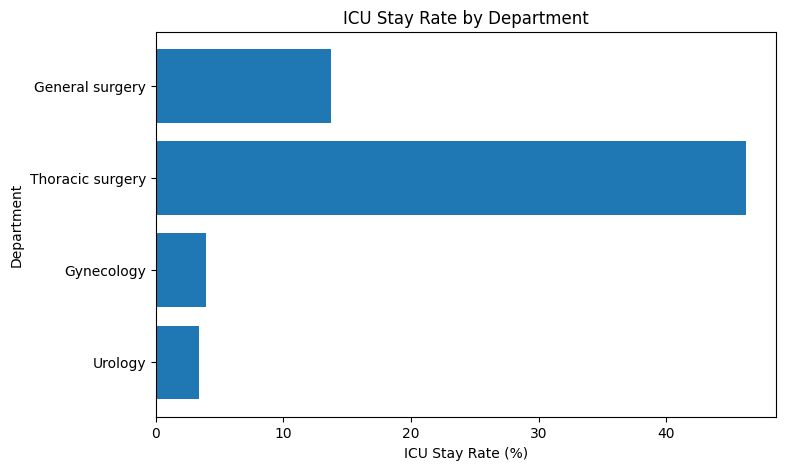

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(
    department_outcomes["department"],
    department_outcomes["icu_stay_rate_pct"]
)
plt.xlabel("ICU Stay Rate (%)")
plt.ylabel("Department")
plt.title("ICU Stay Rate by Department")
plt.gca().invert_yaxis()
plt.show()

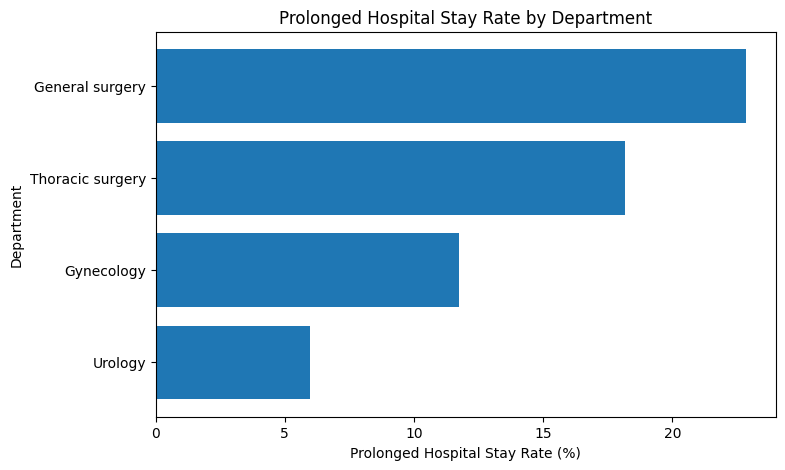

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(
    department_outcomes["department"],
    department_outcomes["prolonged_hospital_stay_rate_pct"]
)
plt.xlabel("Prolonged Hospital Stay Rate (%)")
plt.ylabel("Department")
plt.title("Prolonged Hospital Stay Rate by Department")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Case Volume by Operation Type

operation_type_counts = analysis_df["operation_type"].value_counts().reset_index()
operation_type_counts.columns = ["operation_type", "case_count"]

operation_type_counts

,operation_type,case_count
0,Colorectal,1350
1,Biliary/Pancreas,812
2,Others,799
3,Stomach,676
4,Major resection,584
5,Minor resection,553
6,Breast,434
7,Transplantation,403
8,Vascular,262
9,Hepatic,258


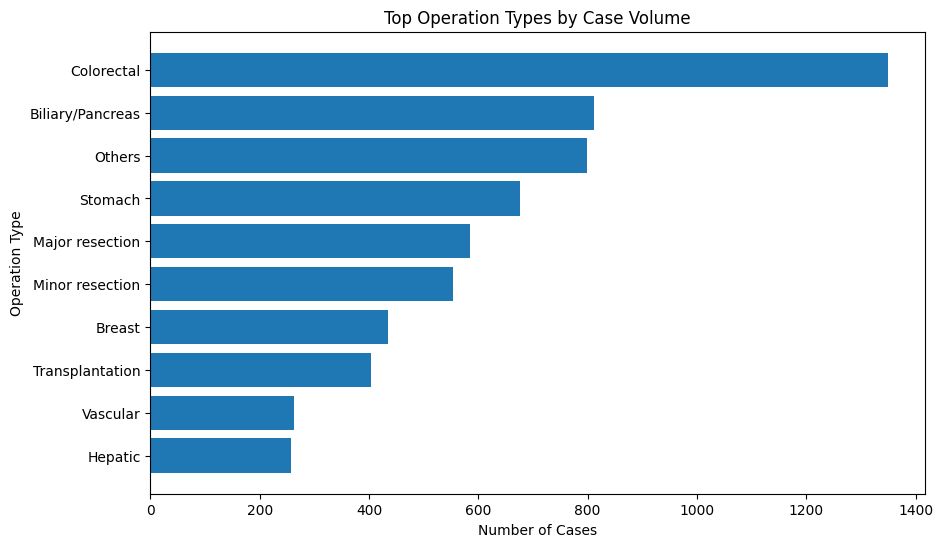

In [ ]:
top_operation_types = operation_type_counts.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_operation_types["operation_type"], top_operation_types["case_count"])
plt.xlabel("Number of Cases")
plt.ylabel("Operation Type")
plt.title("Top Operation Types by Case Volume")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Outcomes by Operation Type

operation_type_outcomes = outcome_summary_by_group(analysis_df, "operation_type")

operation_type_outcomes

,operation_type,case_count,mortality_rate,icu_stay_rate,prolonged_hospital_stay_rate,avg_icu_days,avg_hospital_length_of_stay,mortality_rate_pct,icu_stay_rate_pct,prolonged_hospital_stay_rate_pct
2,Colorectal,1350,0.006667,0.043704,0.142222,0.111852,8.500741,0.666667,4.370370,14.222222
0,Biliary/Pancreas,812,0.003695,0.125616,0.183498,0.203202,7.854680,0.369458,12.561576,18.349754
6,Others,799,0.030038,0.277847,0.396746,1.551940,19.337922,3.003755,27.784731,39.674593
7,Stomach,676,0.005917,0.149408,0.306213,0.276627,12.594675,0.591716,14.940828,30.621302
4,Major resection,584,0.010274,0.506849,0.119863,0.715753,7.986301,1.027397,50.684932,11.986301
5,Minor resection,553,0.000000,0.253165,0.061483,0.323689,6.300181,0.000000,25.316456,6.148282
1,Breast,434,0.004608,0.002304,0.043779,0.002304,6.419355,0.460829,0.230415,4.377880
9,Transplantation,403,0.009926,0.439206,0.600496,2.198511,19.352357,0.992556,43.920596,60.049628
10,Vascular,262,0.011450,0.278626,0.232824,0.870229,8.305344,1.145038,27.862595,23.282443
3,Hepatic,258,0.007752,0.116279,0.267442,0.282946,12.112403,0.775194,11.627907,26.744186


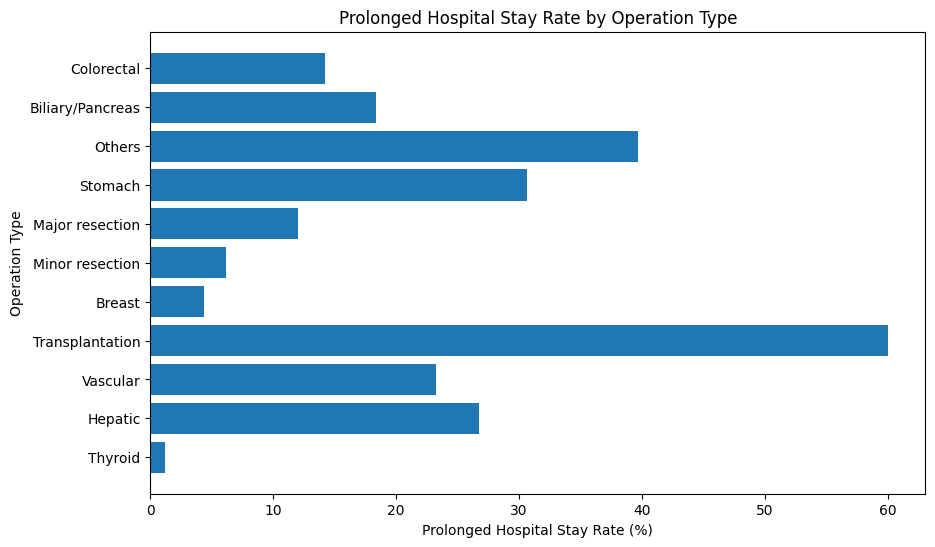

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    operation_type_outcomes["operation_type"],
    operation_type_outcomes["prolonged_hospital_stay_rate_pct"]
)
plt.xlabel("Prolonged Hospital Stay Rate (%)")
plt.ylabel("Operation Type")
plt.title("Prolonged Hospital Stay Rate by Operation Type")
plt.gca().invert_yaxis()
plt.show()

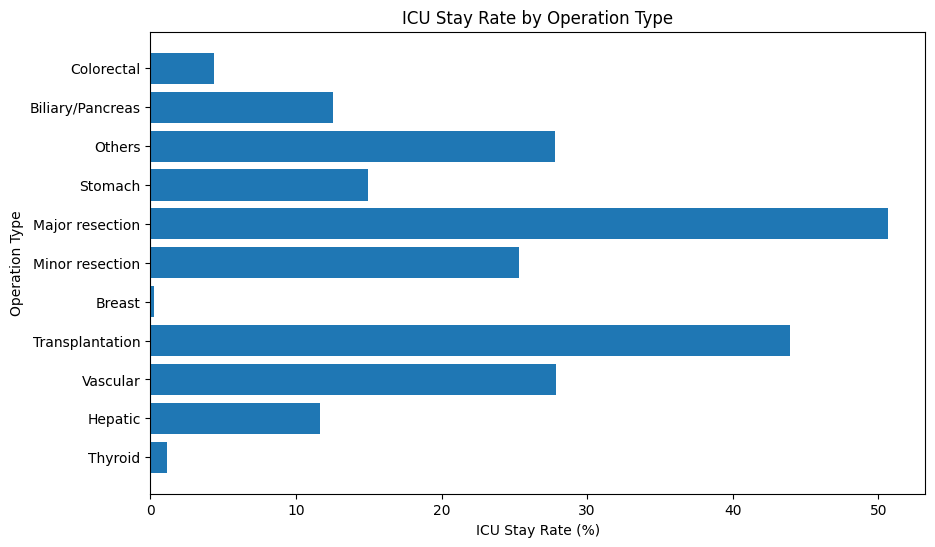

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    operation_type_outcomes["operation_type"],
    operation_type_outcomes["icu_stay_rate_pct"],
)
plt.xlabel("ICU Stay Rate (%)")
plt.ylabel("Operation Type")
plt.title("ICU Stay Rate by Operation Type")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Outcomes by ASA Class

asa_summary = outcome_summary_by_group(analysis_df, "asa_class")
asa_summary = asa_summary.sort_values("asa_class")

asa_summary

,asa_class,case_count,mortality_rate,icu_stay_rate,prolonged_hospital_stay_rate,avg_icu_days,avg_hospital_length_of_stay,mortality_rate_pct,icu_stay_rate_pct,prolonged_hospital_stay_rate_pct
0,1.0,1792,0.005022,0.059710,0.083147,0.080357,6.613281,0.502232,5.970982,8.314732
1,2.0,3699,0.004596,0.188429,0.198162,0.356042,9.675588,0.459584,18.842931,19.816167
2,3.0,703,0.024182,0.455192,0.568990,1.775249,19.933144,2.418208,45.519203,56.899004
3,4.0,48,0.250000,0.916667,0.833333,14.979167,63.750000,25.000000,91.666667,83.333333
4,6.0,13,0.000000,0.230769,0.769231,0.230769,67.692308,0.000000,23.076923,76.923077


In [ ]:
# Emergency vs Non-Emergency Surgery

emergency_summary = outcome_summary_by_group(analysis_df, "emergency_operation_label")

emergency_summary

,emergency_operation_label,case_count,mortality_rate,icu_stay_rate,prolonged_hospital_stay_rate,avg_icu_days,avg_hospital_length_of_stay,mortality_rate_pct,icu_stay_rate_pct,prolonged_hospital_stay_rate_pct
1,Non-emergency,5606,0.004995,0.167321,0.179094,0.319122,9.243489,0.499465,16.732073,17.909383
0,Emergency,782,0.037084,0.340153,0.459079,2.227621,19.283887,3.708440,34.015345,45.907928


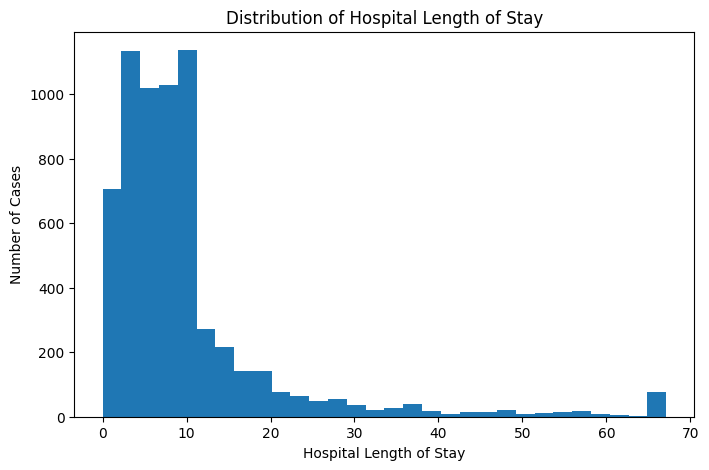

In [ ]:
# Hospital Length of Stay Distribution

los_99 = analysis_df["hospital_length_of_stay"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    analysis_df["hospital_length_of_stay"].clip(upper=los_99),
    bins=30
)
plt.xlabel("Hospital Length of Stay")
plt.ylabel("Number of Cases")
plt.title("Distribution of Hospital Length of Stay")
plt.show()

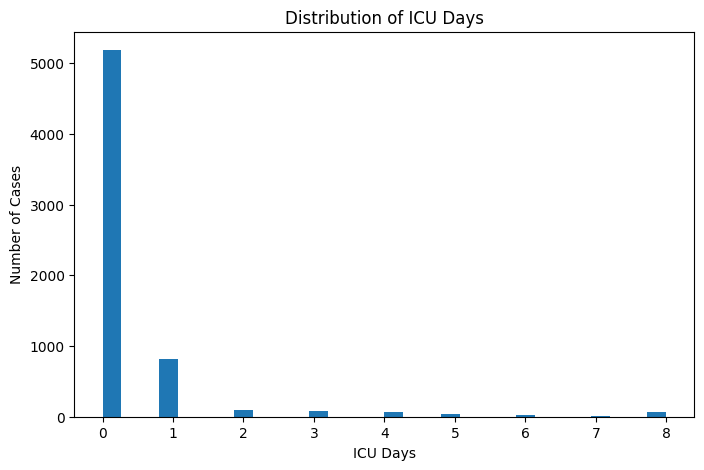

In [ ]:
# ICU Days Distribution

icu_99 = analysis_df["icu_days"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    analysis_df["icu_days"].clip(upper=icu_99),
    bins=30
)
plt.xlabel("ICU Days")
plt.ylabel("Number of Cases")
plt.title("Distribution of ICU Days")
plt.show()

In [ ]:
# Correlation with Outcomes

numeric_cols = analysis_df.select_dtypes(include=["int64", "float64"]).columns

corr_df = analysis_df[numeric_cols].corr(numeric_only=True)

corr_df["prolonged_hospital_stay"].sort_values(ascending=False).head(15)

prolonged_hospital_stay                           1.000000
hospital_length_of_stay                           0.583802
intraoperative_crystalloid                        0.366743
had_icu_stay                                      0.359645
asa_class                                         0.336309
intraoperative_urine_output                       0.244196
icu_days                                          0.231657
emergency_operation                               0.224001
intraoperative_colloid                            0.207180
intraoperative_estimated_blood_loss               0.182542
preoperative_creatinine                           0.173962
intraoperative_fresh_frozen_plasma_transfusion    0.116060
in_hospital_death                                 0.088734
preoperative_hypertension                         0.080089
preoperative_diabetes                             0.062681
Name: prolonged_hospital_stay, dtype: float64

In [ ]:
corr_df["in_hospital_death"].sort_values(ascending=False).head(15)

in_hospital_death                                 1.000000
icu_days                                          0.298335
intraoperative_fresh_frozen_plasma_transfusion    0.174101
intraoperative_estimated_blood_loss               0.154026
hospital_length_of_stay                           0.151532
emergency_operation                               0.111847
had_icu_stay                                      0.107504
asa_class                                         0.103950
prolonged_hospital_stay                           0.088734
intraoperative_crystalloid                        0.064686
intraoperative_midazolam                          0.036104
intraoperative_red_blood_cell_transfusion         0.030342
intraoperative_colloid                            0.026774
case_id                                           0.010741
preoperative_hypertension                         0.005289
Name: in_hospital_death, dtype: float64